In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
customer_churn_data = pd.read_excel("../data/raw/telco_churn.xlsx")

# Display first 5 rows
customer_churn_data.head()

In [ ]:
# Print dataset dimensions (rows, columns)
print("Dataset shape:")
print(customer_churn_data.shape)

# Print all column names
print("\nColumns:")
print(customer_churn_data.columns.tolist())

In [ ]:
# Print data types, non-null counts, and memory usage
customer_churn_data.info()

In [ ]:
# Count missing values per column and show only columns with missing data
missing_values = customer_churn_data.isnull().sum()

missing_values[
    missing_values > 0
]  # Filter to show only columns that have at least 1 missing value

In [ ]:
# Create figure with custom size (width=6, height=4)
plt.figure(figsize=(6, 4))

# Create bar plot showing churn distribution (0 = No churn, 1 = Churn)
sns.countplot(data=customer_churn_data, x="Churn Value")

# Add chart labels and title
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Display the plot
plt.show()

In [ ]:
# Create figure with custom size (width=8, height=5)
plt.figure(figsize=(8, 5))

# Create grouped bar plot showing churn distribution across contract types
sns.countplot(
    data=customer_churn_data,
    x="Contract",  # Contract type categories
    hue="Churn Value",  # Color bars by churn status (0/1)
)

# Add chart labels and title
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Display the plot
plt.show()

In [ ]:
# Create figure with custom size (width=8, height=5)
plt.figure(figsize=(8, 5))

# Create box plot comparing monthly charges between churned and non-churned customers
sns.boxplot(
    data=customer_churn_data,
    x="Churn Value",  # Churn status (0 = No, 1 = Yes)
    y="Monthly Charges",  # Monthly charges distribution
)

# Add chart labels and title
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

# Display the plot
plt.show()

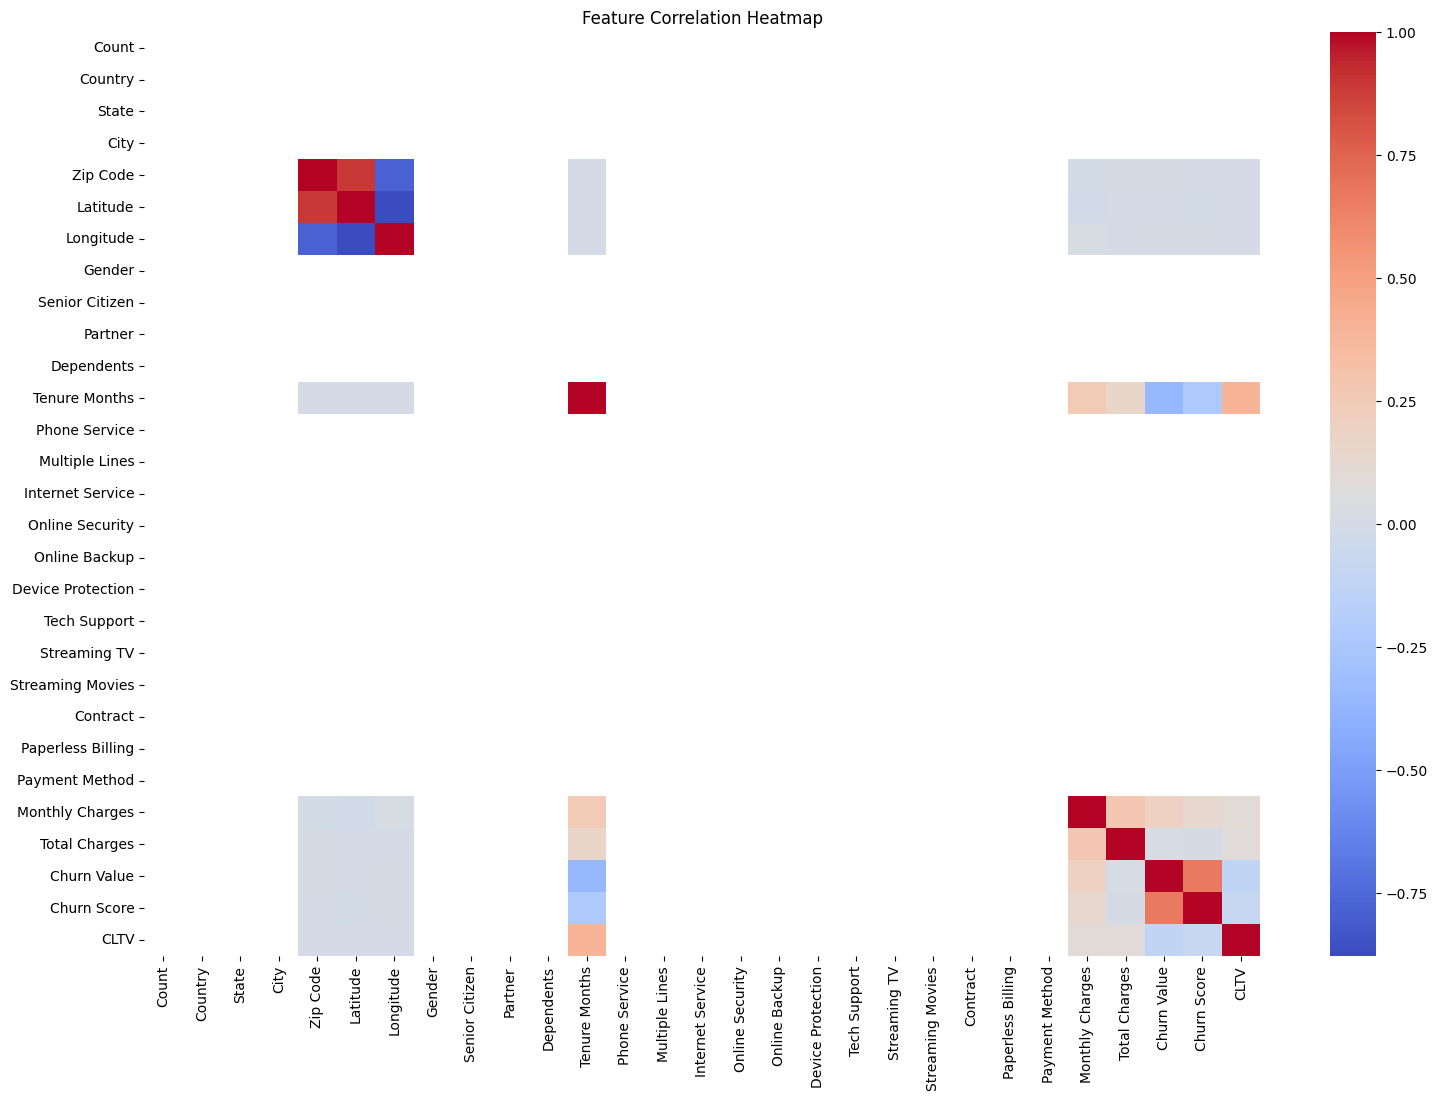

In [10]:
# Create a copy of the original dataset
correlation_data = customer_churn_data.copy()

# Define columns to exclude from correlation analysis
columns_to_remove_for_correlation = [
    "CustomerID",  # Unique identifier (not useful for correlation)
    "Churn Label",  # Redundant with Churn Value
    "Churn Reason",  # Text data, too many categories
    "Lat Long",  # Geographic coordinates combined
]

# Remove unnecessary columns (errors="ignore" prevents errors if columns don't exist)
correlation_data = correlation_data.drop(
    columns=columns_to_remove_for_correlation, errors="ignore"
)

# Encode all categorical columns to numeric values
for column_name in correlation_data.columns:
    if correlation_data[column_name].dtype == "object":  # If column contains text
        column_encoder = LabelEncoder()  # Initialize encoder
        correlation_data[column_name] = column_encoder.fit_transform(
            correlation_data[column_name].astype(str)  # Convert to string then encode
        )

# Convert all columns to numeric (coerce non-numeric to NaN)
correlation_data = correlation_data.apply(pd.to_numeric, errors="coerce")
correlation_data = correlation_data.fillna(0)  # Replace NaN with 0

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Create heatmap figure
plt.figure(figsize=(18, 12))

# Plot correlation heatmap
sns.heatmap(
    correlation_matrix, cmap="coolwarm"  # Red = positive, Blue = negative correlation
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
import joblib
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

# Load trained model from disk
trained_model = joblib.load("../src/models/churn_model.pkl")

# Create a copy of the original dataset
model_data = customer_churn_data.copy()

# Define columns to remove (target, leakage, and irrelevant columns)
columns_to_remove = [
    "Churn Value",  # Target variable
    "Churn Label",  # Leakage (same as Churn Value)
    "Churn Score",  # Leakage (calculated after churn)
    "Churn Reason",  # Leakage (only known after churn)
    "CustomerID",  # Unique identifier
    "CLTV",  # Customer Lifetime Value (leakage)
    "Count",  # Constant value
    "Lat Long",  # Combined geographic field
    "Latitude",  # Too granular
    "Longitude",  # Too granular
]

# Separate features (X) by removing target/leakage columns
feature_data = model_data.drop(columns=columns_to_remove)

# Encode all categorical features to numeric
for column_name in feature_data.columns:
    if feature_data[column_name].dtype == "object":  # If column contains text
        encoder = LabelEncoder()  # Initialize encoder
        feature_data[column_name] = encoder.fit_transform(
            feature_data[column_name].astype(str)  # Convert to string then encode
        )

# Create DataFrame with feature names and their importance scores
feature_importance = pd.DataFrame(
    {
        "Feature": feature_data.columns,
        "Importance": trained_model.feature_importances_,  # From RandomForest
    }
)

# Sort by importance (highest first)
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display top 10 most important features
feature_importance.head(10)

,Feature,Importance
21,Monthly Charges,0.297307
8,Tenure Months,0.273352
22,Total Charges,0.223812
3,Zip Code,0.205529
2,City,0.000000
1,State,0.000000
0,Country,0.000000
6,Partner,0.000000
5,Senior Citizen,0.000000
4,Gender,0.000000
